# DeepSets Model : Simple Aggregation
---

## Accreditation Notes

This notebook relfects a modification of the code associated with the canonical DeepSets model as developed by Zaheer et al. (2017), for the task of determining the sum of a collection of digits sampled randomly from the set {1...9}. The original code is licensed under the Apache License 2.0 (attached) and can be sourced at https://github.com/manzilzaheer/DeepSets. The following modifications have been considered:
- No LSTM or GRU model comparisons are considered
- Model creation has been generified with exchangable encoding and decoding components
- Dataset creation has been generified with a generic labelling function

### Imports

In [43]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '0'
import matplotlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from IPython.display import SVG
import keras.backend as K
from keras.layers import Input, Dense, LSTM, GRU, Embedding, Lambda
from keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint
from keras.utils.vis_utils import model_to_dot
from tqdm import tqdm,trange

### Global Parameters

In [44]:
# TRAINING PARAMETERS
n_train = 100000 # number of training examples
max_train = 10 # maximum cardinality of a training set member

# TESTING PARAMETERS
n_test = 10000 # number of testing examples
min_test = 5 # maximum cardinality of a testing set member
max_test = 100 # minimum cardinality of a testing set member
step_test = 5 # interval through which cardinalities of set members are tested

# SET FUNCTION TO APPROXIMATE
labelling_function = lambda S: np.sum(S)

## Generating Training Data

In [45]:
# Begin with only masked entries
X_train = np.zeros((n_train,max_train))
label_X_train = np.zeros((n_train))

# For the desired number of training examples
for i in tqdm(range(n_train), desc='Generating train examples: '):
    
    # Generate a random set cardianality
    n = np.random.randint(1,max_train)
    for j in range(1,n+1):

        # Sample desired members from established distribution, fill from the right
        X_train[i,-j] = np.random.randint(1,10)

    # Add to dataset
    label_X_train[i] = labelling_function(X_train[i])



Generating train examples: 100%|██████████| 100000/100000 [00:02<00:00, 35254.22it/s]


## Generating Testing Data

In [46]:
def gen_test_data(num_examples, length):

    # Begin with only masked entries
    X_test = np.zeros((num_examples, length))
    label_X_test = np.zeros((num_examples))

    # For the desired number of testing examples
    for i in range(num_examples):
        
        # Testing set member is always of fixed cardinality
        for j in range(1,length+1):

             # Sample desired members from established distribution, fill from the right
            X_test[i,-j] = np.random.randint(1,10)

        # Add to dataset
        label_X_test[i] = labelling_function(X_test[i])

    return X_test, label_X_test

## Generating a Deep Sets Model

In [47]:
class DeepSetsModelFactory:
  def __init__(self, max_length, input=None, embedding=None, encoder=None, aggregation=None, decoder=None, optimizer=None, loss=None): 

    # Assign the maximum number of set elements
    self._max_length = max_length

    # Assign the input format, defaults to simple scalar inputs
    self._input = input

    # Assign an embedding
    self._embedding = embedding

    # Assign the encoder, defaults to simple NN
    self._encoder = encoder

    # Assign the aggregation mechanism - defaults to summation
    self._aggregation = aggregation

    # Assign the decoder, defaults to simple NN
    self._decoder = decoder

    # Assign optimizer, defualts to adam
    self._optimizer = optimizer

    # Assign loss function, defualts to mae
    self._loss = loss


  def build(self):
    input = self._input
    x = self._embedding(input)
    x = self._encoder(x)
    x = self._aggregation(x)
    encoding = self._decoder(x)
    m = Model(input, encoding)
    m.compile(optimizer=self._optimizer, loss=self._loss)
    return m

## Training

In [42]:
model_configs = {
  "max_length":max_train,
  "input":Input(shape=(max_train,)),
  "embedding":Embedding(11, 100, mask_zero=True),
  "encoder":Dense(30, activation='tanh'),
  "aggregation":Lambda(lambda x: K.sum(x, axis=1), output_shape=(lambda shape: (shape[0], shape[2]))),
  "decoder":Dense(1),
  "optimizer":Adam(learning_rate=1e-4, epsilon=1e-3),
  "loss":'mae'    
}

# create a model
model = DeepSetsModelFactory(
    **model_configs
).build()

# train
checkpointer = ModelCheckpoint(
    filepath='/tmp/weights.hdf5', 
    verbose=0, 
    save_best_only=True
)

model.fit(
    X_train, 
    label_X_train, 
    epochs=10, 
    batch_size=128,
    shuffle=True, 
    validation_split=0.0123456789,
    callbacks=[checkpointer]
)

model = load_model('/tmp/weights.hdf5')

# save weights
deep_we = []
for i in [1,2,4]:
    w = model.get_layer(index=i).get_weights()
    deep_we.append(w)

Epoch 1/10
772/772 [==============================] - 3s 3ms/step - loss: 13.3502 - val_loss: 3.5102
Epoch 2/10
772/772 [==============================] - 2s 3ms/step - loss: 1.1302 - val_loss: 0.0122
Epoch 3/10
772/772 [==============================] - 2s 3ms/step - loss: 0.0117 - val_loss: 0.0045
Epoch 4/10
772/772 [==============================] - 2s 3ms/step - loss: 0.0081 - val_loss: 0.0120
Epoch 5/10
772/772 [==============================] - 2s 3ms/step - loss: 0.0093 - val_loss: 0.0075
Epoch 6/10
772/772 [==============================] - 2s 3ms/step - loss: 0.0076 - val_loss: 0.0069
Epoch 7/10
772/772 [==============================] - 2s 3ms/step - loss: 0.0085 - val_loss: 0.0051
Epoch 8/10
772/772 [==============================] - 2s 3ms/step - loss: 0.0072 - val_loss: 0.0047
Epoch 9/10
772/772 [==============================] - 2s 3ms/step - loss: 0.0083 - val_loss: 0.0021
Epoch 10/10
772/772 [==============================] - 2s 3ms/step - loss: 0.0078 - val_loss: 0.021

In [54]:
metrics = {'deepsets': {'acc':[], 'mae':[], 'mse':[]}}

lengths = range(min_test, max_test, step_test)
for l in lengths:
    print('Evaluating at length: ', l)
    K.clear_session()
    
    # generate test data
    X_test, label_X_test = gen_test_data(n_test, l)

    # model
    model_configs['max_length'] = l
    model_configs['input'] = Input(shape=(l,))
    model = DeepSetsModelFactory(**model_configs).build()

    # load weights
    for i, idx in enumerate([1,2,4]):
        model.get_layer(index=idx).set_weights(deep_we[i])

    # prediction
    preds = model.predict(X_test, batch_size=128, verbose=1)
    metrics['deepsets']['acc'].append(1.0*np.sum(np.squeeze(np.round(preds))==label_X_test)/len(label_X_test))
    metrics['deepsets']['mae'].append(np.sum(np.abs(np.squeeze(preds)-label_X_test))/len(label_X_test))
    metrics['deepsets']['mse'].append(np.dot(np.squeeze(preds)-label_X_test, np.squeeze(preds)-label_X_test)/len(label_X_test))

Evaluating at length:  5
79/79 [==============================] - 0s 2ms/step
Evaluating at length:  10
79/79 [==============================] - 0s 2ms/step
Evaluating at length:  15
79/79 [==============================] - 0s 2ms/step
Evaluating at length:  20
79/79 [==============================] - 0s 2ms/step
Evaluating at length:  25
79/79 [==============================] - 0s 2ms/step
Evaluating at length:  30
79/79 [==============================] - 0s 3ms/step
Evaluating at length:  35
79/79 [==============================] - 0s 3ms/step
Evaluating at length:  40
79/79 [==============================] - 0s 3ms/step
Evaluating at length:  45
79/79 [==============================] - 0s 3ms/step
Evaluating at length:  50
79/79 [==============================] - 0s 3ms/step
Evaluating at length:  55
79/79 [==============================] - 0s 3ms/step
Evaluating at length:  60
79/79 [==============================] - 0s 4ms/step
Evaluating at length:  65
79/79 [====================

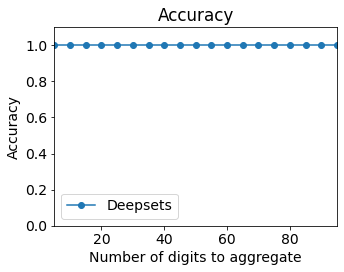

In [55]:
font = {'size': 14}
matplotlib.rc('font', **font)

scale = 0.5
plt.figure(figsize=(10*scale, 8*scale))

plt.plot(lengths, metrics['deepsets']['acc'], 'o-')
plt.xlabel('Number of digits to aggregate')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.ylim( 0, 1.1 )
plt.xlim( 5, 95 )
plt.legend(['Deepsets'], fontsize=14)
plt.tight_layout()
plt.show()

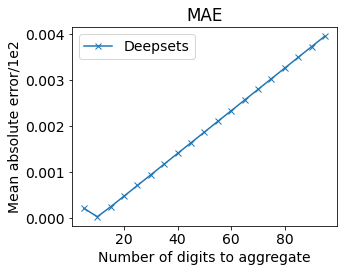

In [56]:
font = {'size': 14}
matplotlib.rc('font', **font)

scale = 0.5
plt.figure(figsize=(10*scale, 8*scale))

plt.plot(lengths, np.array(metrics['deepsets']['mae'])/1e2, 'x-')
plt.xlabel('Number of digits to aggregate')
plt.ylabel('Mean absolute error/1e2')
plt.title('MAE')
plt.legend(['Deepsets'], fontsize=14)
plt.tight_layout()
plt.show()

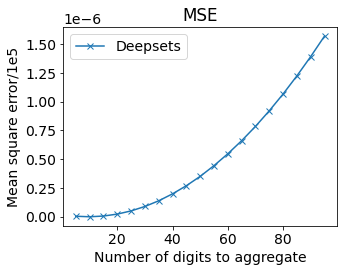

In [57]:
font = {'size': 14}
matplotlib.rc('font', **font)

scale = 0.5
plt.figure(figsize=(10*scale, 8*scale))

plt.plot(lengths, np.array(metrics['deepsets']['mse'])/1e5, 'x-')
plt.xlabel('Number of digits to aggregate')
plt.ylabel('Mean square error/1e5')
plt.title('MSE')
plt.legend(['Deepsets'], fontsize=14)
plt.tight_layout()
plt.show()